# PHYS 771 Assignment 1 due June 17 2026 11:59pm

The goal of this exercise will be to calculate the radial velocity curve of a planetary system discovered by the Kepler satellite (Crossfield et al. 2015; http://arxiv.org/abs/ 1501.03798). You will study the feasibility of measuring the masses of these planets with a high-resolution spectrometer that reaches the meter per second precision. These three Super-Earth planets were discovered around an M-type low-mass star (named K2−3) with the transit method. The physical parameters of the planets are given in Table 2 of the paper. For this exercise, we will suppose that all three planets have co-planar and circular orbits, with an inclination of exactly 90 degrees. We will also suppose that the impact parameter of the transit is null and that all arguments of pericentre are equal at 90 degrees.

#### 0. Imports

In [1]:
import astropy.units as u
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

### a) Determine the masses of the three planets, in units of Earth masses. Assume that K2−3 b and K2−3 c have volumetric densities equal to that of Jupiter (1.33 g/cm3) and that K2−3 d has a volumetric density equal to that of the Earth (5.5 g/cm3).

In [2]:
# volumetric densities assumptions 
rho_K2b = 1.33 * u.g / u.cm**3
rho_K2c = 1.33 * u.g / u.cm**3
rho_K2d = 5.5 * u.g / u.cm**3

In [3]:
# planet radii from Table 2 of the paper
R_K2b = 2.14 * u.earthRad
R_K2c = 1.72 * u.earthRad
R_K2d = 1.52 * u.earthRad

In [4]:
# Mass-radius relations from section 2.6 of the paper 
def MassRadius(radius, density):
    """ 
    radius: Rearth 
    density: g/cm**3
    """
    if radius < 1.5 * u.earthRad:
        mass = ((4*np.pi)/3 ) * radius**3 * density 

        if (mass.cgs.unit != u.g):
            print("Units error")
            return None

        return mass

    if radius >= 1.5 * u.earthRad and radius < 4.0 * u.earthRad:
        mass = (2.69 * u.earthMass) * (radius.value)**0.93

        if (mass.cgs.unit != u.g):
            print("Units error")
            return None

        return mass

    if radius >= 4.0 * u.earthRad:
        mass = (1.0 * u.earthMass) * (radius.value)**2.06 

        if (mass.cgs.unit != u.g):
            print("Units error")
            return None

        return mass 

    print('Mistakes have been made.')
    return None

In [5]:
# compute masses from the relations above
M_K2b = MassRadius(R_K2b,rho_K2b)
M_K2c = MassRadius(R_K2c,rho_K2c)
M_K2d = MassRadius(R_K2d,rho_K2d)

In [6]:
print(f"Mass of K2-3b: {M_K2b:.3f}")
print(f"Mass of K2-3c: {M_K2c:.3f}")
print(f"Mass of K2-3d: {M_K2d:.3f}")

Mass of K2-3b: 5.458 earthMass
Mass of K2-3c: 4.454 earthMass
Mass of K2-3d: 3.971 earthMass


### b) Determine the expected radial velocity semi-amplitude (K) for each planet.

In [7]:
# star mass from Table 1 
Mstar = 0.601 * u.solMass

# inclination and eccentricities are given assumptions 
i = 90.0 
e = 0.0

# planet periods from Table 2
P_K2b = 10.05403 * u.day
P_K2c = 24.6454 * u.day
P_K2d = 44.5631 * u.day

In [8]:
# We use the formula from the RV lecture notes (2.26)
def semiAmplitude(period, Mp, Mstar, i, e):
    """ 
    Period: days
    Mp: earthMass 
    Mstar: solMass
    i: unitless float
    e: unitless float
    """ 

    K = ((2*np.pi*const.G)/period)**(1/3) *  (Mp * np.sin(np.deg2rad(i))/((Mstar+Mp)**(2/3)) ) * ( 1/((1-e**2)**(1/2)) )
    
    if (K.cgs.unit != (u.cm/u.s)):
        print("Units error")
        return None

    return K.to(u.m/u.s)

In [9]:
# compute RV semi-amplitudes using the formula 
K_K2b = semiAmplitude(P_K2b, M_K2b, Mstar, i, e)
K_K2c = semiAmplitude(P_K2c, M_K2c, Mstar, i, e)
K_K2d = semiAmplitude(P_K2d, M_K2d, Mstar, i, e)

In [10]:
print(f"RV Semi-amplitude of K2-3b: {K_K2b:.3f}")
print(f"RV Semi-amplitude of K2-3c: {K_K2c:.3f}")
print(f"RV Semi-amplitude of K2-3d: {K_K2d:.3f}")

RV Semi-amplitude of K2-3b: 2.271 m / s
RV Semi-amplitude of K2-3c: 1.374 m / s
RV Semi-amplitude of K2-3d: 1.006 m / s


### c) Determine the radial velocity of the star K2−3 with respect to an observer on Earth,in meters per second at moment t = T0c, where T0c is the epoch of central transit ofthe planet K2−3 c (given in Table 2 of the paper). You can ignore the radial velocity of the center of mass of the K2−3 system, and the Earth’s motion.

In [11]:
# epoch of central transit of each planet from Table 2
T_0b = 1980.4189 * u.day
T_0c = 1979.2786 * u.day
T_0d = 1993.2232 * u.day

# ignored COM motion and Earth motion
v_sys = 0.0 * (u.m /u.s)

# given that the argument of pericenter is 90 deg
w = 90.0

In [12]:
# since we are assuming circular orbits, the true anomaly = mean anomaly so we can use eq from slide 16 of the RV slides
def meanAnomaly(period, t, t_0): 
    """ 
    period: days
    t: days (time we are evaluating at)
    t_0: days (transit time OF THE PLANET)
    """
    nu = (2*np.pi/period) * (t - t_0) 

    if (nu.cgs.unit != u.dimensionless_unscaled):
        print("Units error")
        return None
    return nu * u.rad

In [13]:
# compute the anomalies of each planet at planet c's transit time
nu_K2b_T0c = meanAnomaly(P_K2b, T_0c, T_0b)
nu_K2c_T0c = meanAnomaly(P_K2c, T_0c, T_0c)
nu_K2d_T0c = meanAnomaly(P_K2d, T_0c, T_0d)

In [14]:
print(f"True anomaly of K2-3b at T_0c: {nu_K2b_T0c:.3f}")
print(f"True anomaly of K2-3c at T_0c: {nu_K2c_T0c:.3f}")
print(f"True anomaly of K2-3d at T_0c: {nu_K2d_T0c:.3f}")

True anomaly of K2-3b at T_0c: -0.713 rad
True anomaly of K2-3c at T_0c: 0.000 rad
True anomaly of K2-3d at T_0c: -1.966 rad


In [15]:
# RV of the star due to a planet is given by eq 2.29 from the RV slides 
# N.B. I ignored the long-term linear drift term since we are told to ignore COM motion and Earth motion so I take it that eliminates this drift as well as other systemics
def starRVfromPlanetatTime(K, w, nu, v_sys, e):
    """ 
    K: RV semi-amplitude (m/s)
    w: rad (arg of pericenter)
    nu: rad (anomaly EVALUATED AT TIME t) 
    v_sys: m/s  (systemic velocity)
    e: unitless (eccentricity)
    """

    RV = K * ( np.cos(np.deg2rad(w) + nu.value) + e*np.cos(np.deg2rad(w)) ) + v_sys  

    if (RV.cgs.unit != (u.cm/u.s)):
        print("Units error")
        return None

    return RV.to(u.m/u.s)

In [16]:
# Compute the starRV due to each planet

starRV_K2b_T0c = starRVfromPlanetatTime(K_K2b, w, nu_K2b_T0c, v_sys, e)
starRV_K2c_T0c = starRVfromPlanetatTime(K_K2c, w, nu_K2c_T0c, v_sys, e)
starRV_K2d_T0c = starRVfromPlanetatTime(K_K2d, w, nu_K2d_T0c, v_sys, e)

In [17]:
print(f"RV of star due to K2-3b at T_0c: {starRV_K2b_T0c:.3f}")
print(f"RV of star due to K2-3c at T_0c: {starRV_K2c_T0c:.3f}")
print(f"RV of star due to K2-3d at T_0c: {starRV_K2d_T0c:.3f}")

RV of star due to K2-3b at T_0c: 1.485 m / s
RV of star due to K2-3c at T_0c: 0.000 m / s
RV of star due to K2-3d at T_0c: 0.928 m / s


In [18]:
# Add all the contributions from each planet to obtain the total star RV
starRV_total_T0c = starRV_K2b_T0c + starRV_K2c_T0c + starRV_K2d_T0c

print(f"Total RV of star due to K2-3b,c,d at T_0c: {starRV_total_T0c:.3f}")

Total RV of star due to K2-3b,c,d at T_0c: 2.413 m / s


### d) Plot the radial velocity curve of K2−3 as a function of time in a period of 150 days, starting at T0c. What is the peak-to-peak amplitude of the radial velocity curve ? List your radial velocity values at t = T0c + Δt with Δt = 0, 2, 4, 8, 16, 32, 64 and 128 days.

In [19]:
# time values to print out the RV at
print_out_times = u.Quantity(T_0c.value + np.array([0,2,4,8,16,32,64,128]), u.day)

# time array for x axis 
t_array = u.Quantity(T_0c.value + np.arange(0,151,1,dtype=int), u.day)

In [20]:
# array of planet periods 
P_array = u.Quantity([P_K2b, P_K2c, P_K2d], u.day)

# array of planet transit times 
t_0_array = u.Quantity([T_0b, T_0c , T_0d], u.day)

# array of planet RV semi-amplitudes  
K_array = u.Quantity([K_K2b, K_K2c, K_K2d], u.m/u.s)

In [21]:
# Total star RV as a function of time function 
# N.B. I should've just made it this way in part c but that's okay 
def TotalStarRV(K_array, w, v_sys, e, periods_array, t, t_0_array):
    """ 
    K_array: RV semi-amplitude (m/s)
    w: rad (arg of pericenter)
    v_sys: m/s  (systemic velocity)
    e: unitless (eccentricity)

    periods_array: array of planet's period in days
    t: days 
    t_0_array: array of transit times in days
    """
    RVtot = 0.0 * (u.m/u.s)

    for i in range(len(periods_array)):
        RV_planet = K_array[i] * ( np.cos(np.deg2rad(w) + meanAnomaly(periods_array[i], t, t_0_array[i]).value) + e*np.cos(np.deg2rad(w)) )  

        RVtot = RVtot + RV_planet

    RVtot = RVtot + v_sys # correct for v_sys only once (offsets the entire array), not every planet calc

    if (RVtot.cgs.unit != (u.cm/u.s)):
        print("Units error")
        return None

    return RVtot.to(u.m/u.s)

In [22]:
# Evaluate total star RV over 150 days 
starRVtot = TotalStarRV(K_array, w, v_sys, e, P_array, t_array, t_0_array)

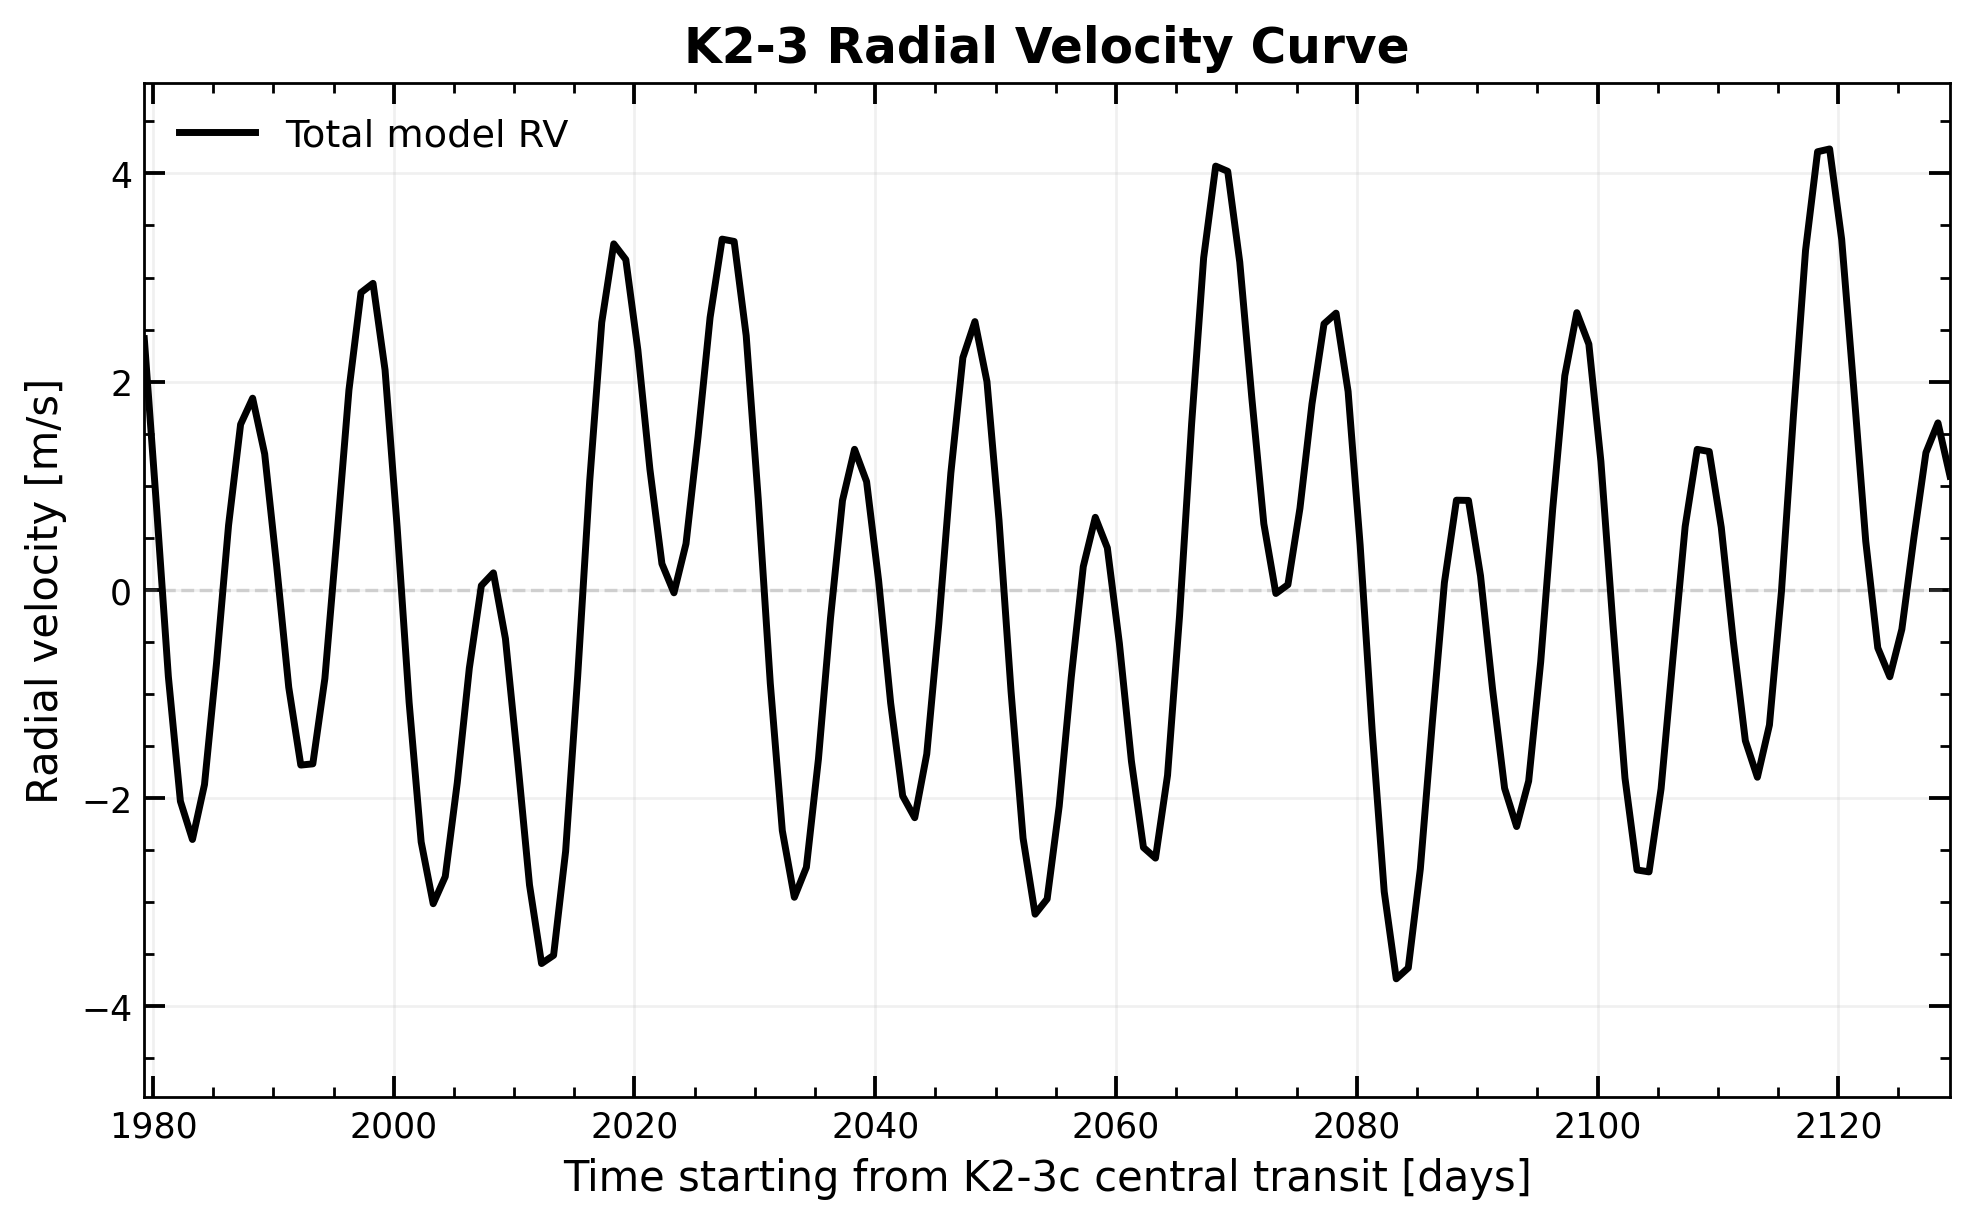


Total RV of K2-3 due to K2-3b, c, and d
----------------------------------------
 Time [days] |      RV [m/s]
----------------------------------------
    1979.279 |        2.413
    1981.279 |       -0.834
    1983.279 |       -2.397
    1987.279 |        1.590
    1995.279 |        0.507
    2011.279 |       -2.835
    2043.279 |       -2.188
    2107.279 |        0.609
----------------------------------------


In [23]:
# Plot the star total RV as a function of time
fig, ax = plt.subplots(figsize=(8, 5), dpi=250)

ax.axhline(0, color='gray', lw=1, ls="--", alpha=0.3)
ax.plot(t_array, starRVtot, color="black", lw=2, label="Total model RV")

ax.set_xlabel("Time starting from K2-3c central transit [days]", fontsize=12)
ax.set_ylabel("Radial velocity [m/s]", fontsize=12)
ax.set_title("K2-3 Radial Velocity Curve", fontsize=14, fontweight="bold")

ax.set_xlim(t_array[0].value, t_array[-1].value)

# make y-limits symmetric around zero
rv_absmax = max(abs(starRVtot.value.min()), abs(starRVtot.value.max()))
ax.set_ylim(-1.15 * rv_absmax, 1.15 * rv_absmax)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.legend(frameon=False, fontsize=11, loc="best")


fig.tight_layout()
plt.show()



# Print asked values
print("\nTotal RV of K2-3 due to K2-3b, c, and d")
print("-" * 40)
print(f"{'Time [days]':>12} | {'RV [m/s]':>13}")
print("-" * 40)

for time in print_out_times:
    print(f"{time.value:12.3f} | {starRVtot[np.where(t_array == time)][0].value:12.3f}")

print("-" * 40) 

### e) Simulate some observations of this radial velocity curve on the span of the 150days used in d). The sampling of the observations is one measurement per day at a precision of 1 m/s. To simulate the measurement errors, draw random noise from a Gaussian distribution centered on the true radial velocity at each epoch, with a standard deviation of 1 m/s. Plot these simulated measurements (with the appropriate error bars) on top of the expected radial velocity curve.

In [24]:
# Gaussian parameters
stdev = 1.0 #m/s 
mean = 0.0 #will center on RV value when added on top of data
sampling = np.arange(0,151,1,dtype=int) # 1 measurement per day for 150 days

# Gaussian noise curve
rng = np.random.default_rng(0)  # fixed seed so the plot is reproducible (otherwise random seed everytime)

noise = rng.normal(
    loc=mean, 
    scale=stdev, 
    size= len(sampling)
    ) * (u.m / u.s)

# Data with noise added
starRV_obs = starRVtot + noise

In [25]:
# Error bars setup
RV_err = np.ones_like(t_array.value) * (stdev * u.m / u.s)

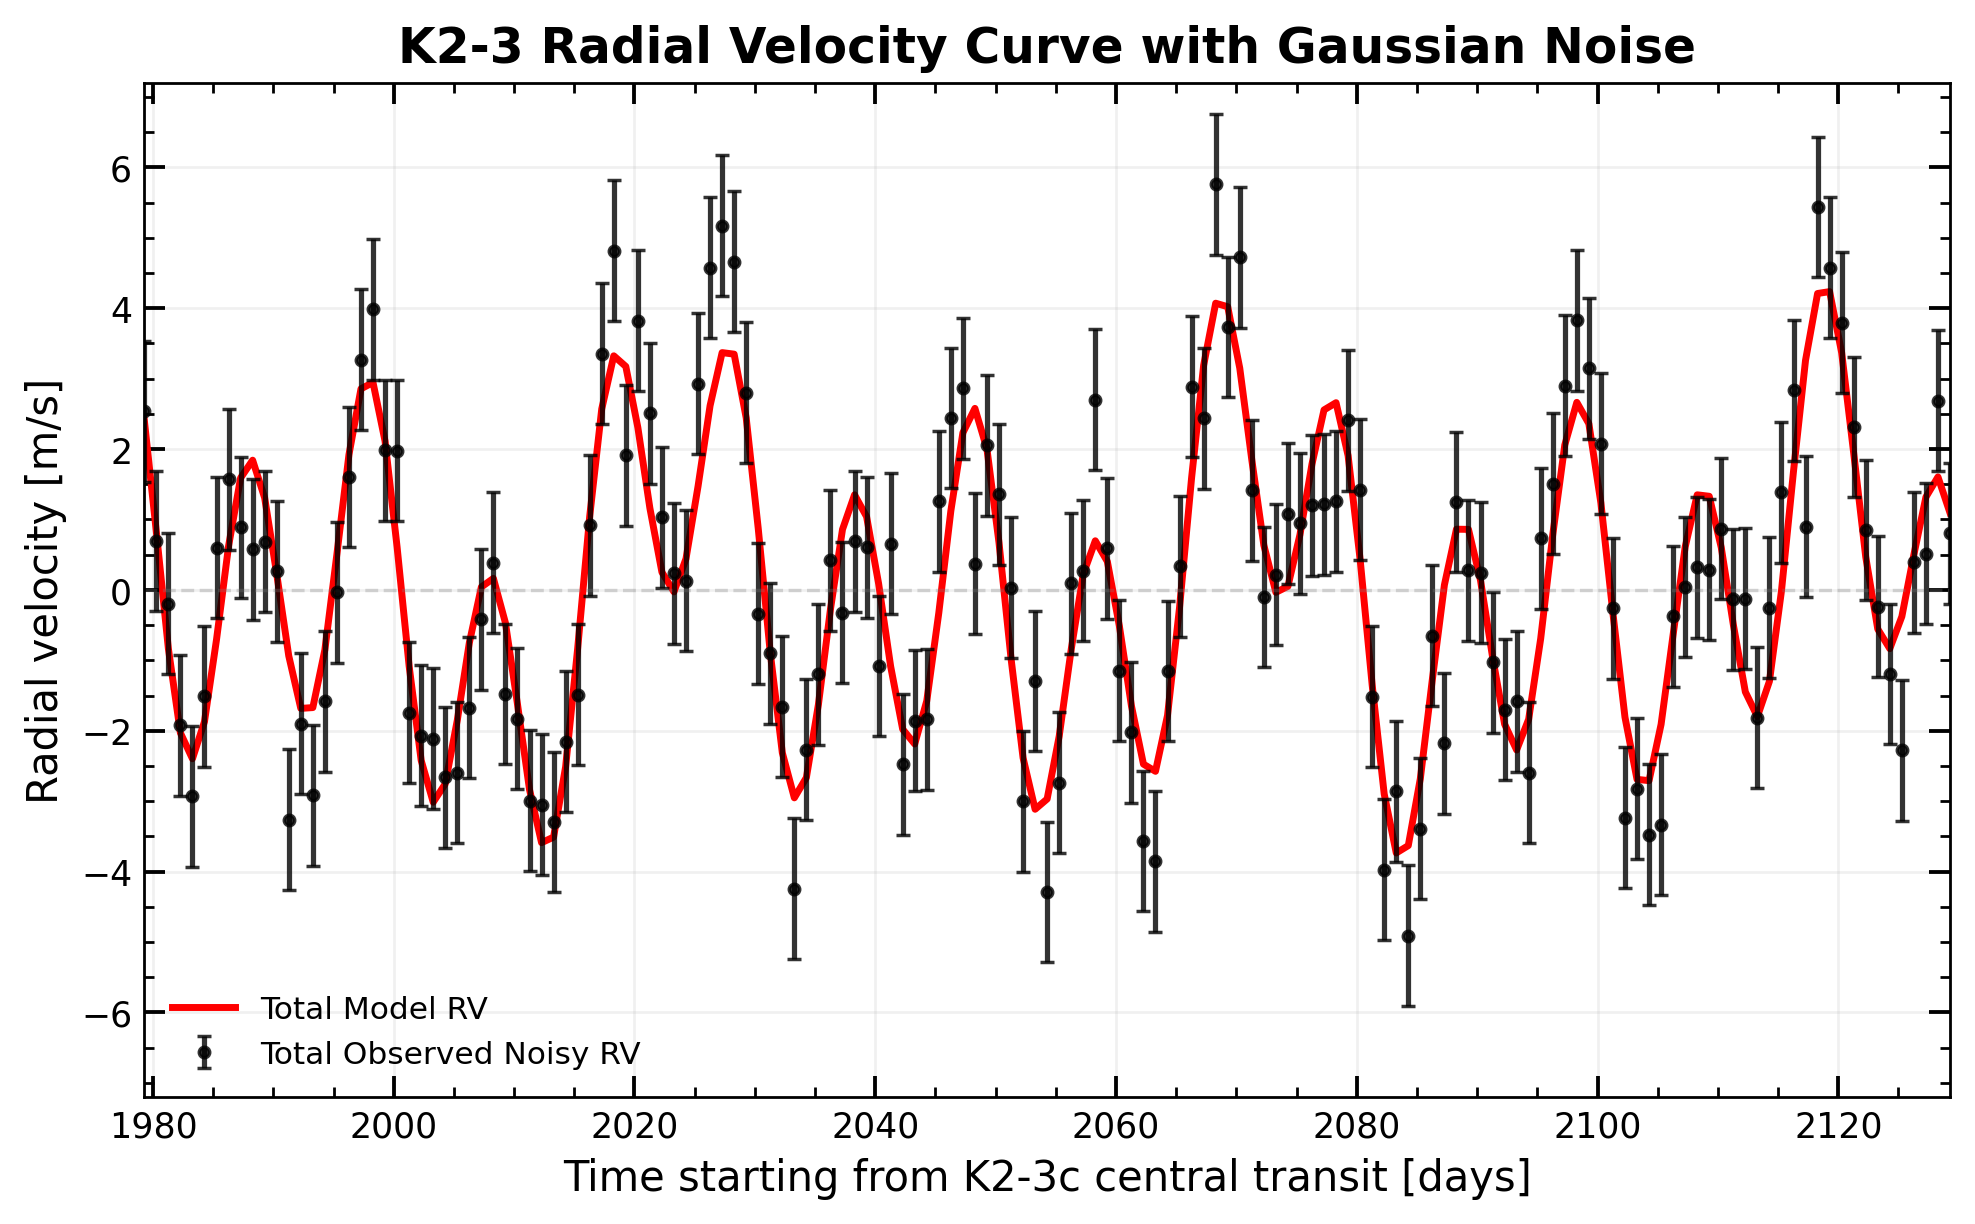

In [26]:
# Plot the star total RV as a function of time with error bars
fig, ax = plt.subplots(figsize=(8, 5), dpi=250)

ax.plot(t_array, starRVtot, color="red", lw=2, label="Total Model RV", zorder = 2)
# Error bars 
ax.errorbar(
    t_array.value,
    starRV_obs.value,
    yerr=RV_err.value,
    fmt="o",
    ms=3.0,
    color='black',
    alpha=.8,
    capsize=2,
    label="Total Observed Noisy RV",
    #lw = 1
)
ax.axhline(0, color='gray', lw=1, ls="--", alpha=0.3)

ax.set_xlabel("Time starting from K2-3c central transit [days]", fontsize=12)
ax.set_ylabel("Radial velocity [m/s]", fontsize=12)
ax.set_title("K2-3 Radial Velocity Curve with Gaussian Noise", fontsize=14, fontweight="bold")

ax.set_xlim(t_array[0].value, t_array[-1].value)

# make y-limits symmetric around zero
rv_absmax = max(abs(starRV_obs.value.min()), abs(starRV_obs.value.max()))
ax.set_ylim(-1.25 * rv_absmax, 1.25 * rv_absmax)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.legend(frameon=False, fontsize=9, loc="best")


fig.tight_layout()
plt.show()

### f) What periodigram algorithm would be most appropriate for this problem, and why ? Use any software or code of your choice to calculate the periodigram of your simulated radial velocity curve, and see if you can detect the periodic signal associated with each planet.

After some quick research I've found a couple of options: Fourier Transforms (FFT), Welch Method, Lomb-Scargle Periodigram (LSP), Box-fitting Least squares (BLS), etc. 

FFT is best adapted to evenly spaced data which eliminates it. Welch's method needs a continuous signal which I don't think works well in astrophysics where we can't get continuous data most of the time, also this case has sampling too low to be considered continuous in my opinion. It seems to me like LSP and BLS are the most well adapted for astrophysical time-series data that is unevenly spaced and with varying resolution. BLS fits to a box shape which makes it well suited for transits but not quite right for this case. LSP is the best option as it evaluates data points using a least-squares fit to sine and cosine waves without boxing the data like BLS. 

In other words, RV data are noisy time-series, and real astronomical observations are often unevenly sampled as well. Lomb-Scargle is designed to find sinusoidal periodic signals in noisy, unevenly sampled data, which makes it the most appropriate for this use case.

In [37]:
# Periodigram algorithm 
from astropy.timeseries import LombScargle

frequency, power = LombScargle(t_array, starRV_obs, RV_err).autopower()
period = frequency**(-1)

I've chosen to only plot Periods with 2 < P < 76 days because we are only sampling once a day (so minimum two days to see a second transit) and for a window of 150 days (we can only see two transits from planets that have periods less than half our observation window)

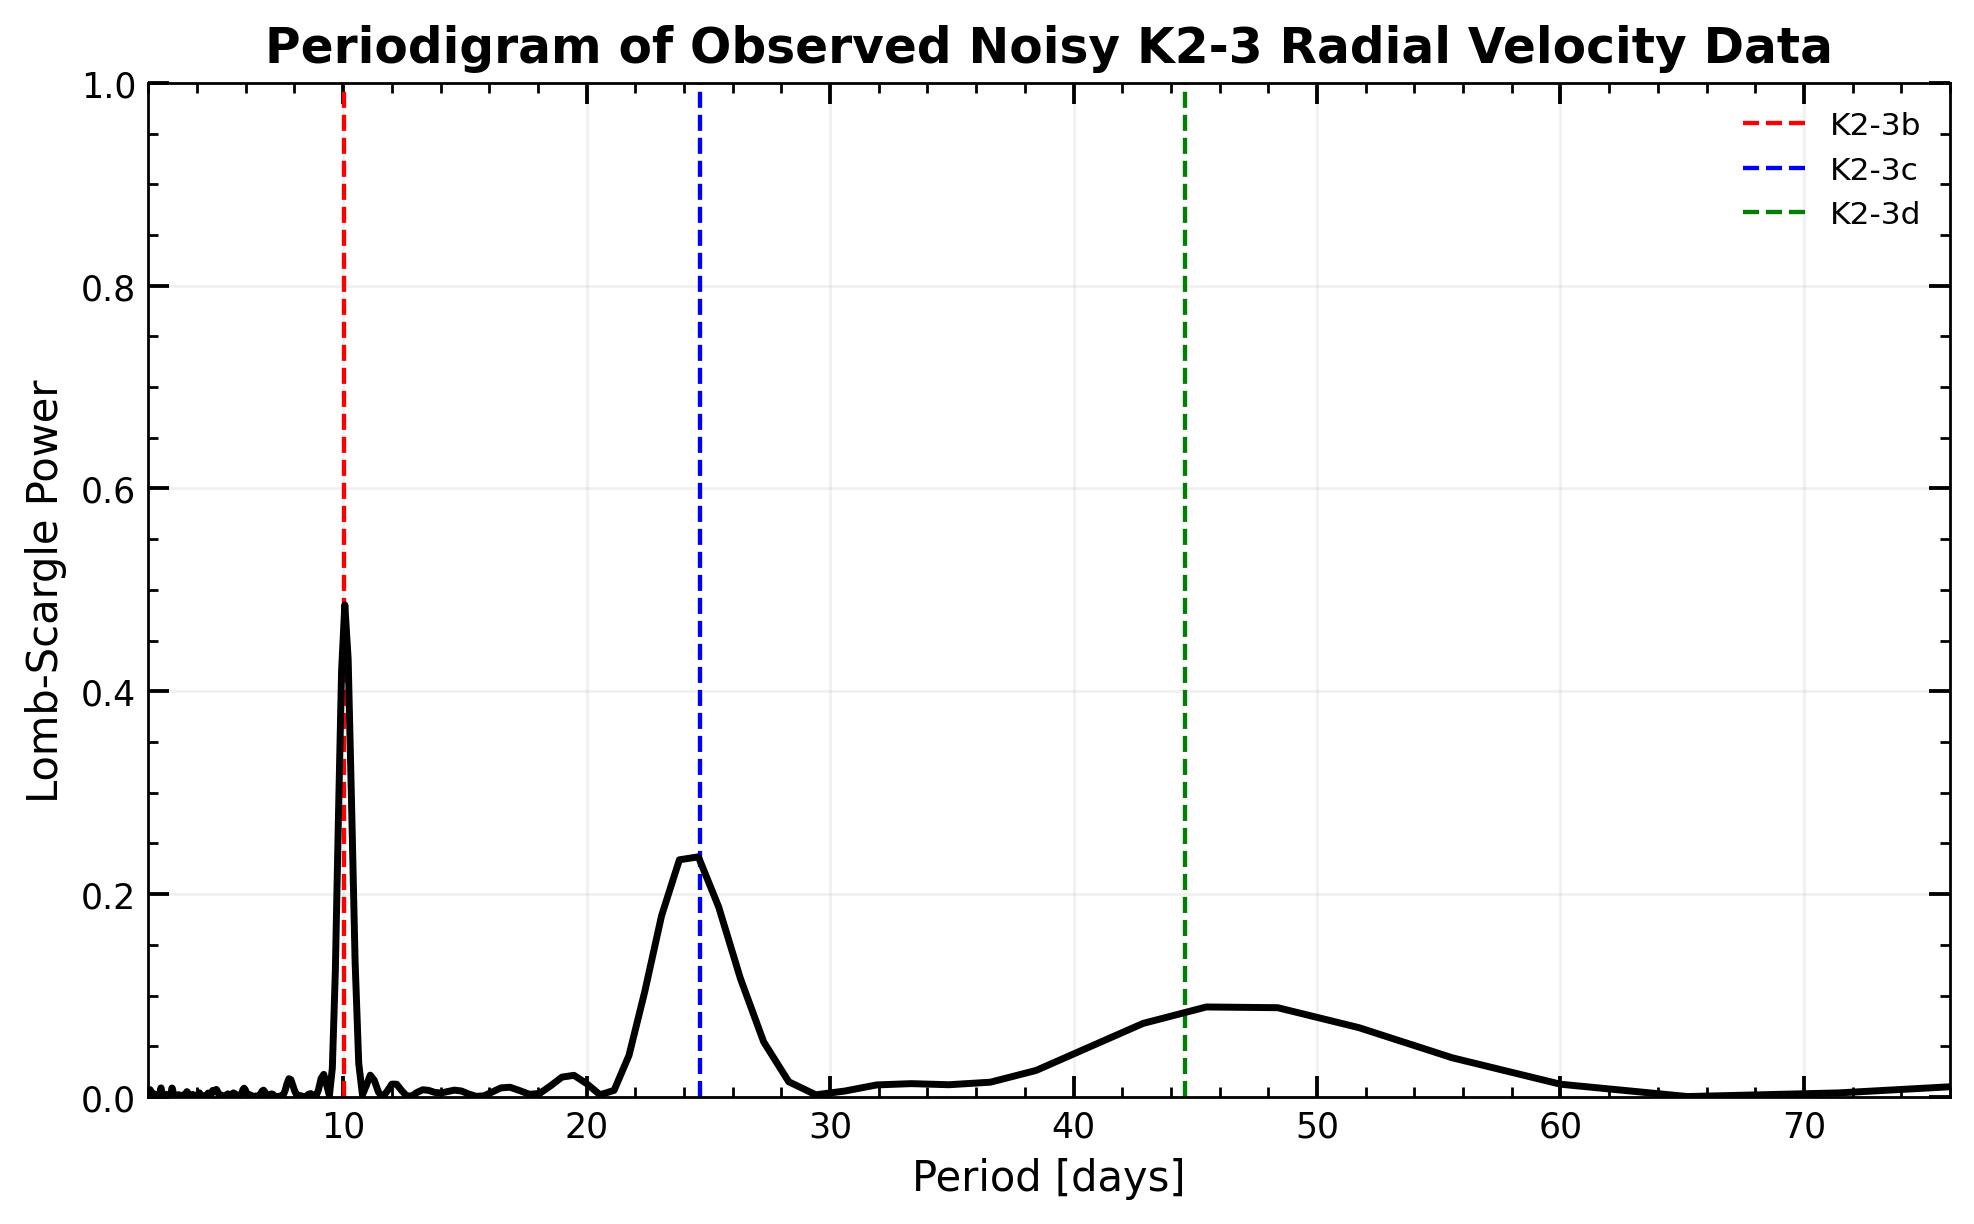

In [56]:
# Plot the Periodigram
fig, ax = plt.subplots(figsize=(8, 5), dpi=250)

# Label known planet periods
ax.axvline(P_K2b.value, color="red", lw = 1.25, ls="--", label="K2-3b")
ax.axvline(P_K2c.value, color="blue", lw = 1.25, ls="--", label="K2-3c")
ax.axvline(P_K2d.value, color="green", lw = 1.25, ls="--", label="K2-3d")

ax.plot(period, power, color="black", lw=2)

ax.set_xlabel("Period [days]", fontsize=12)
ax.set_ylabel("Lomb-Scargle Power", fontsize=12)
ax.set_title("Periodigram of Observed Noisy K2-3 Radial Velocity Data", fontsize=14, fontweight="bold")

ax.set_xlim(2, 76)
ax.set_ylim(0,1)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.legend(frameon=False, fontsize=9, loc="best")

fig.tight_layout()
plt.show()

Yes we detect the ~10 days, ~25 days and ~44 days periods of our three planets. Although it seems that the added noise makes it difficult to detect the exact value of the K2-3d period; the value doesn't match the local maximum.